
# Unidad 4:
​
## Ecuaciones diferenciales
- EDO Simbólico
- Metodo de Euler
- Método de Verlet
- Runge-kuta
​

## Introducción

Las ecuaciones diferenciales son sin duda una de las ramas más útiles de las matemáticas en la ciencia. Se utilizan para modelar problemas que implican el cambio de una variable con respecto a otra. Las ecuaciones diferenciales cubren una amplia gama de aplicaciones diferentes, que van desde ecuaciones diferenciales ordinarias (EDO) hasta problemas de valor límite que involucran muchas variables. En aras de la simplicidad, a lo largo de esta sección cubriremos solo los sistemas EDO, ya que son más elementales e igualmente útiles. Primero, cubriremos los métodos de primer orden, luego los métodos de segundo orden y finalmente, el sistema de ecuaciones diferenciales.

Las ecuaciones diferenciales ordinarias normalmente implican la solución de un problema de valor inicial, es decir, la solución tiene que satisfacer la ecuación diferencial junto con alguna condición inicial. Los problemas de la vida real generalmente implican problemas muy complicados e incluso no solubles, lo que hace inviable cualquier aproximación analítica. Afortunadamente, hay dos formas de manejar esto. Primero, para casi todas las situaciones, generalmente es posible simplificar el problema original y obtener uno más simple que pueda resolverse fácilmente. Luego, utilizando la teoría de la perturbación, podemos perturbar esta solución para aproximarnos a la real. Este enfoque es útil, sin embargo, depende mucho del problema específico y un estudio sistemático es bastante complicado.

La segunda aproximación, y la utilizada aquí, consiste en una reducción numérica completa del problema, resolviéndolo exactamente dentro de la precisión permitida por los errores implícitos de los métodos. Para esta parte, vamos a asumir problemas bien definidos, donde se espera que las soluciones se comporten bien.


### Definición de ecuación diferencial
Una ecuación que tenga derivadas de cualquier orden en sus términos es una ecuación diferencial, por ejemplo considere las siguientes ecuaciones y su solución:
$\newcommand{\sen}{\,\hbox{sen}\,}$

$$
\begin{array}{l}
1)\quad \dfrac{dy}{dt}= -ky &\iff& y(t)=Ae^{-kt}\\
2)\quad \dfrac{d^2y}{dt^2}+ \omega_0^2y= 0  &\iff&  y(t)=A\cos(\omega_0 t) + B\sen(\omega_0 t),\\
3)\quad \dfrac{d^2y}{dt^2}+ \omega_0 \sen y= A\cos(\alpha t-\pi/3)&\iff& \text{No hay solución analítica},\\
4)\quad \dfrac{d^3y}{dt^3}+t^2y\dfrac{d^2y}{dt^2} - 3y(y+t)=0&\iff& \text{No hay solución analítica.}
\end{array}
$$

Como vemos no todas tienen solución analítica directa, pero existen varios métodos numéricos para resolver estas ecuaciones.

### Orden y clasificación de las ecuaciones diferenciales

El orden es determinado por la derivada más alta en la ecuación, así la ecuación 1) es de orden uno, la 2) y 3) de orden dos, y la última de orden tres. Por otro lado,
La clasificación se da de acuerdo a si la ecuación es lineal o no lineal, una EDO es lineal si la variable a integrar se puede separar del operador $\mathcal{L}$ formado por las derivadas, osea un ecuación diferencial es lineal si,

$$\mathcal{L}y(t)=f(t),$$

por ejemplo para la primera EDO,

$$ \left(\frac{d}{dt} + k\right)y(t)=\mathcal{L} y(t)=0.$$

Así, las ecuaciones 1) y 2) son lineales pero la 3) y 4) no.

## Sistemas de EDO de primer orden

Un sistema de $n$ ecuaciones diferenciales es lineal (es decir, no hay términos como $y_i^2, 1/y_i$ o $y_iy_j$, por ejemplo) si se puede escribir de la forma,

$$\dfrac{dy_1}{dt}=a_{11}y_1 + a_{12}y_2 + \cdots a_{1n}y_n,$$
$$\dfrac{dy_2}{dt}=a_{21}y_1 + a_{22}y_2 + \cdots a_{2n}y_n,$$
$$\vdots$$
$$\dfrac{dy_n}{dt}=a_{n1}y_1 + a_{n2}y_2 + \cdots a_{nn}y_n.$$

Si se define $\mathbf{y}(t)= (y_1(t),y_2(t),..., y_n(t))$, la forma matricial y su solución es,

$$\quad \frac{d\mathbf{y}}{dt}= A\mathbf{y}\iff \mathbf{y}=\exp(At)\mathbf{y}_0$$

donde $\mathbf{y}_0=\mathbf{y}(t_0)$ es la condición inicial y $A$ es una matriz $n\times n$, la solución se hace por los métodos matriciales de diagolalización. Si $A(t)$ varía con el tiempo entonces la solución es,

$$\mathbf{y}(t)=\exp\left(\int_{t_0}^tA(t')dt'\right)\mathbf{y}_0.$$

En el caso de sistemas no lineales las ecuaciones acopladas se escriben de la forma,

$$\frac{d\mathbf{y}}{dt}=\mathbf{y}' =\mathbf{f}(t,\mathbf{y}),$$

note que, $\mathbf{f}(t,\mathbf{y})\neq A\mathbf{y}$, estos sistemas de EDO no tienen solución analítica (solo algunos casos) y se deben resolver de manera numérica, sistemas como el de Eduard Lorenz o el oscilador armónico para ángulos grandes son ejemplos de sistemas no lineales, en este documento se mostrarán los diferentes métodos numéricos para la solución de sistemas EDO:  Método de Euler, Métodos de verlet y leapfrog, Runge-Kuta (rk2, rk4 y rk45).  


## Cálculo Simbólico

Primero miremos un poco el calculo simbólico con sympy.

## Máquina de Atwood

La longitud de la cuerda en la polea de radio $R$ estará compuesta por:

$$ x+y+\pi R = l \quad \rightarrow \quad y = -x + \pi R-l$$
Entonces obtenemos:
$$ \dot{y} = - \dot{x} $$

Siendo $x$ e $y$, longitudes de las cuerdas de $m_1$ y $m_2$.


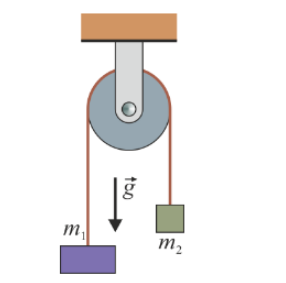

In [ ]:
import matplotlib.pyplot as plt

import numpy as np
import sympy as sym



In [ ]:
#notacion punto
import sympy.physics.mechanics as mech
mech.init_vprinting()

In [ ]:
R,m1,m2,g,L=sym.symbols('R,m_1,m_2,g,L', positive=True)

t=sym.symbols('t')

x=sym.Function('x')

y=-x(t)+ (L-sym.pi*R)
y

L - π⋅R - x

In [ ]:
# Energía cinética (T)
# x.diff(t), y.diff(t) : velocidades
T=sym.Rational(1,2)*m1*(x(t).diff(t)**2) + sym.Rational(1,2)*m2* (y.diff(t)**2)
T#.simplify()

    2       2
m₁⋅ẋ    m₂⋅ẋ 
───── + ─────
  2       2  

In [ ]:
# Energía potencial (U)

U= -m1*g*x(t) - m2*g*y
U#.simplify()

-g⋅m₁⋅x - g⋅m₂⋅(L - π⋅R - x)

In [ ]:
Lagr= T-U
Lagr#.simplify()

                                  2       2
                              m₁⋅ẋ    m₂⋅ẋ 
g⋅m₁⋅x + g⋅m₂⋅(L - π⋅R - x) + ───── + ─────
                                2       2  

In [ ]:
rhs=Lagr.diff(x(t))
rhs

g⋅m₁ - g⋅m₂

In [ ]:
lhs= Lagr.diff(x(t).diff(t)).diff(t)
lhs

m₁⋅ẍ + m₂⋅ẍ

**Euler-Lagrange equation**:

$$ \frac{d}{dt} \left( \frac{\partial L}{\partial \dot x} \right) - \frac{\partial L}{\partial x} = 0$$

In [ ]:
E_L=sym.Eq(lhs,rhs)
E_L

m₁⋅ẍ + m₂⋅ẍ = g⋅m₁ - g⋅m₂

**Finalmente resolvemos la ecuación diferencial:**
$$\ddot{x}=\frac{g(m_1-m_2)}{(m_1+m_2)}$$

In [ ]:
g_pos = sym.dsolve(E_L) #posición general
g_pos

                   2          
                g⋅t ⋅(m₁ - m₂)
x = C₁ + C₂⋅t + ──────────────
                 2⋅(m₁ + m₂)  

**Reemplazando valores iniciales**

$$x(0)=0, \qquad \left.\frac{dx}{dt}\right|_0=0$$

In [ ]:
ics={x(0): 0, sym.diff(x(t), t).subs(t,0): 0}

In [ ]:
pos_eq = sym.dsolve(E_L,ics=ics) # reemplazsando condiciones iniciales
pos_eq #ecuación de posición

       2          
    g⋅t ⋅(m₁ - m₂)
x = ──────────────
     2⋅(m₁ + m₂)  

In [ ]:
pos= pos_eq.rhs #solo la parte derecha
pos

   2          
g⋅t ⋅(m₁ - m₂)
──────────────
 2⋅(m₁ + m₂)  

In [ ]:
vel=pos.diff(t)
vel

g⋅t⋅(m₁ - m₂)
─────────────
   m₁ + m₂   

**Reemplazando valores numéricos**

$$m_1=10, \quad m_2=5, \quad g=9.8$$

In [ ]:
pos= pos.subs([(g,9.8),(m1,10),(m2,5)])
pos

                  2
1.63333333333333⋅t 

In [ ]:
#pasar de simbolica a numerica
np_pos=sym.lambdify(t,pos,'numpy')

Text(0.5, 1.0, 'Máquina de Atwood - m1= 10Kg , m2=5kg, g=9.8')

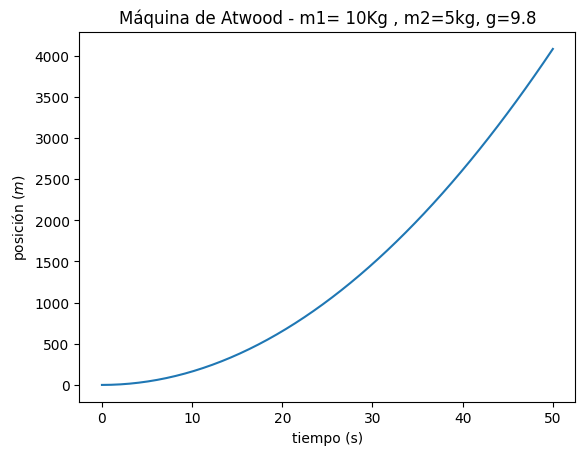

In [ ]:
tt=np.linspace(0,50)
pos_numpy=np_pos(tt)
plt.plot(tt,pos_numpy)

plt.xlabel('tiempo (s)')
plt.ylabel('posición $(m)$')
plt.title('Máquina de Atwood - m1= 10Kg , m2=5kg, g=9.8')

**Ejercicio**: Ley de enfriamiento de Newton

Ley que describe como un objeto con una temperatura inicial  $T(t_0)=T_0$ es enfriado en una temperatura ambiente $T_R$

$$\frac{dT(t)}{dt}=-k\Delta T =-k(T(t)-T_R)$$

$\frac{dT(t)}{dt}$ nos dice la taza de enfriamiento de un objeto es proporcional a la diferencia de temperaturas.

Cuya solución analítica es:

$$T(t)=T_R+(T(0)-T_R)e^{-kt}$$

Solucione de forma simbólica y compare con la solución análitica.

In [ ]:
Tr,t,k,T0=sym.symbols('Tr,t,k,T0')
Tt=sym.Function('T')
dTdt=Tt(t).diff(t)
exp=sym.Eq(dTdt,-k*(Tt(t)-Tr))
exp

Ṫ = -k⋅(-Tr + T)

In [ ]:
sym.dsolve(exp)

        -k⋅t     
T = C₁⋅ℯ     + Tr

In [ ]:
ics2={Tt(0):T0}
Eq_sol=sym.dsolve(exp,ics=ics2)
Eq_sol

                    -k⋅t
T = Tr + (T₀ - Tr)⋅ℯ    

## Método de Euler
Considere la ecuación diferencial,

$$\frac{dy}{dt}= f(t, y),  \,\,\,   a \le t \le b, \,\,\, y(a) = \alpha.$$

No se obtendrá una aproximación continua a la solución $y(t)$; en su lugar, las aproximaciones se generarán para varios valores llamados **puntos de malla** en el intervalo $[a,b]$.

Una vez que se obtiene la solución aproximada en los puntos, la solución aproximada en otros puntos en el intervalo se puede encontrar a través de interpolación.

primero estipulamos que los puntos de malla están Igualmente espaciados a lo largo del intervalo $[a,b]$. Esta copndición se garantiza al seleccionar un entero positivo $N$, al establecer $h=(b-a)/N$, y seleccionar los puntos de malla

$$t_i=a+ih, \qquad i=0,1,2,..,N.$$ Entonces por expansión de taylor hasta el orden dos de $y(t)$ y usando la ecuación anterior para remplazar la derivada $y'(t_n)$, por $f (t_n, y(t_n))$, tenemos,

$$y(t_{n+1}) = y(t_n) + hf (t_n, y(t_n)) + \frac{h^2}{2} y''(\xi_n),$$

por lo tanto el método de euler se define como,

$$y_{n+1} \approx y_n + hf(t_n,y_n).$$

El "*error local*" o "*error de truncación local*" mide a cada paso la cantidad por la cual la solución aproximada falla en satisfacer la ecuación diferencial y acorde a la ecuación diferencial, es definido por,

$$\boxed{\tau(h) \overset{\text{def}}{=} \frac{y_{n+1} - y_n}{h} - f(t_n,y_n)=\frac{h}{2}y''(\xi_n).}$$

por lo tanto este método es de primer orden $O(h)$.


**Ejercicio** Implemente el método de euler en python y uselo para comprobar la solución de la ley de enfriamiento de newton.

In [ ]:
def euler(f,x0,xn,y0,n):

    h=(xn-x0)/n
    x0_l=[]
    yn_l=[]

    for i in range(n):
        slope=f(x0,y0)
        yn=y0+h*slope
        y0=yn
        x0=x0+h
        x0_l.append(x0)
        yn_l.append(yn)

    return yn_l

In [ ]:
#k=0.07
def newton(time,temp):
    return -0.07*(temp-20)

def newton_ana(t,Tr=20,T0=100,k=0.07):
    return Tr+(T0-Tr)*np.exp(-k*t)

In [ ]:
a=0
b=100
N1=10
N2=100
h1=(b-a)/N1
h2=(b-a)/N2

t_T=np.linspace(a,b,N2)
Tem=euler(newton,a,b,100,N2)
Tem_ana=newton_ana(t_T)

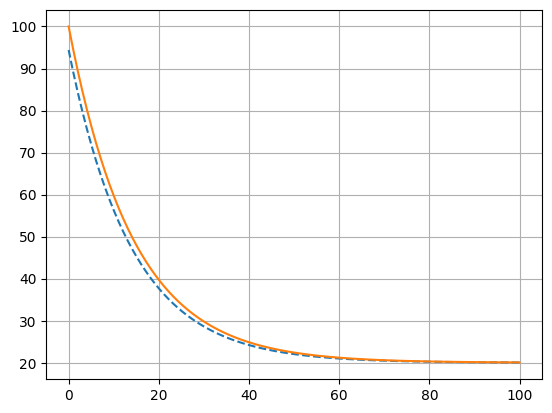

In [ ]:
fig=plt.figure()

plt.plot(t_T,Tem,'--')
plt.plot(t_T,Tem_ana)

plt.grid()
plt.show()